Import Tools

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# Deep Learning Tools
from tensorflow.keras import layers, models
import keras
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPool2D
from keras.layers import Activation, Dropout, BatchNormalization, Flatten, Dense
from keras.optimizers import Adam
from keras.utils import to_categorical


# Machine Learning Tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

Data Loading

In [23]:
import os
import cv2
from tqdm import tqdm


# Use absolute path
base_path = r'c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Datasets\COVID-19\COVID-19_Radiography_Dataset'

print(f"Checking path: {base_path}")
print(f"Path exists: {os.path.exists(base_path)}")

# Image paths
imagePaths = []
for dirname, _, filenames in os.walk(base_path):
    # Only process files inside the 'images' folder
    if 'images' in dirname:
        for filename in filenames:
            if filename.endswith('.png'):  # Consider only PNG files
                imagePaths.append(os.path.join(dirname, filename))
print(f"Found {len(imagePaths)} images")  # Add this to verify

Checking path: c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Datasets\COVID-19\COVID-19_Radiography_Dataset
Path exists: True
Found 21165 images


Image Preprocessing

In [24]:
# Data - Label
Data = []
Target = []
resize = 150

# Label mapping dictionary
cat = {'COVID': 'Covid-19','Lung_Opacity': 'Lung_Opacity','Normal': 'Normal','Viral Pneumonia': 'Pneumonia'}

# Iterate through the image paths and assign the labels
for imagePath in tqdm(imagePaths):
    label = imagePath.split(os.path.sep)[-3]  # Extract the label from parent folder (2 levels up from image)
    
    if label not in cat:
        continue  # Skip this image if label is not found in dictionary
    
    image = cv2.imread(imagePath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (resize, resize)) / 255.0  # Normalize image pixels to [0, 1]

    Data.append(image)
    Target.append(cat[label])

print(f"Processed {len(Data)} images with corresponding labels.")

100%|██████████| 21165/21165 [11:15<00:00, 31.33it/s]

Processed 21165 images with corresponding labels.


In [25]:
print(len(Data))
print(len(Target))

21165
21165


Label Encoding and to One Hot encoding
Examples (4 classes - alphabetically ordered):

[[1., 0., 0., 0.], # 'Covid-19' -> [1, 0, 0, 0]

[0., 1., 0., 0.], # 'Lung_Opacity' -> [0, 1, 0, 0]

[0., 0., 1., 0.], # 'Normal' -> [0, 0, 1, 0]

[0., 0., 0., 1.]] # 'Pneumonia' -> [0, 0, 0, 1]

In [28]:
# encode labels as integers

le = LabelEncoder()
labels = le.fit_transform(Target)
labels = to_categorical(labels)

print(le.classes_)
print(labels[0])

['Covid-19' 'Lung_Opacity' 'Normal' 'Pneumonia']
[1. 0. 0. 0.]


Splitting Dataset

In [29]:
# Initial split
(x_train, x_test, y_train, y_test) = train_test_split(Data, labels, test_size=0.20, stratify=labels, random_state=42)

# Further split the training data into training and validation sets
(x_train, x_val, y_train, y_val) = train_test_split(x_train, y_train, test_size=0.20, stratify=y_train, random_state=42)


trainX = np.array(x_train)
valX = np.array(x_val)
testX = np.array(x_test)
trainY = np.array(y_train)
valY = np.array(y_val)
testY = np.array(y_test)

print("Training data shape:", trainX.shape)
print("Validation data shape:", valX.shape)
print("Testing data shape:", testX.shape)
print("Training labels shape:", trainY.shape)
print("Validation labels shape:", valY.shape)
print("Testing labels shape:", testY.shape)

Training data shape: (13545, 150, 150, 3)
Validation data shape: (3387, 150, 150, 3)
Testing data shape: (4233, 150, 150, 3)
Training labels shape: (13545, 4)
Validation labels shape: (3387, 4)
Testing labels shape: (4233, 4)


CNN Model Training

In [30]:
# Define the model
s = 150  # Size

model = Sequential()


# Feature Extraction Parts
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=(s, s, 3), kernel_initializer='he_normal'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(1, 1)))
model.add(Dropout(0.25))


# ann = dense layers

# Nueral Network (Dense Layers)
model.add(Flatten())  # 
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(4, activation="softmax"))



# Compile the model
model.compile(optimizer=keras.optimizers.Adam(),loss=keras.losses.categorical_crossentropy,metrics=['accuracy'])

# Train the model with validation data
epochs = 25
history = model.fit(trainX, trainY, epochs=epochs, batch_size=40, verbose=1, validation_data=(valX, valY))

c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Project\Medical_Image_Analysis_System\backend\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 178s 506ms/step - accuracy: 0.6367 - loss: 1.3040 - val_accuracy: 0.8102 - val_loss: 0.5124
Epoch 2/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 132s 390ms/step - accuracy: 0.8047 - loss: 0.4955 - val_accuracy: 0.8051 - val_loss: 0.5002
Epoch 3/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 129s 381ms/step - accuracy: 0.8451 - loss: 0.4088 - val_accuracy: 0.8606 - val_loss: 0.3649
Epoch 4/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 108s 318ms/step - accuracy: 0.8697 - loss: 0.3413 - val_accuracy: 0.8609 - val_loss: 0.3832
Epoch 5/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 106s 311ms/step - accuracy: 0.8960 - loss: 0.2816 - val_accuracy: 0.8772 - val_loss: 0.3534
Epoch 6/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 106s 313ms/step - accuracy: 0.9081 - loss: 0.2443 - val_accuracy: 0.8784 - val_loss: 0.3411
Epoch 7/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 111s 327ms/step - accuracy: 0.9192 - loss: 0.2084 - val_accuracy: 0.8775 - val_loss: 0.3445
Epoch 8/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 132s 388ms/step - accuracy: 0.9342 -

Extract accuracy and loss from the history object

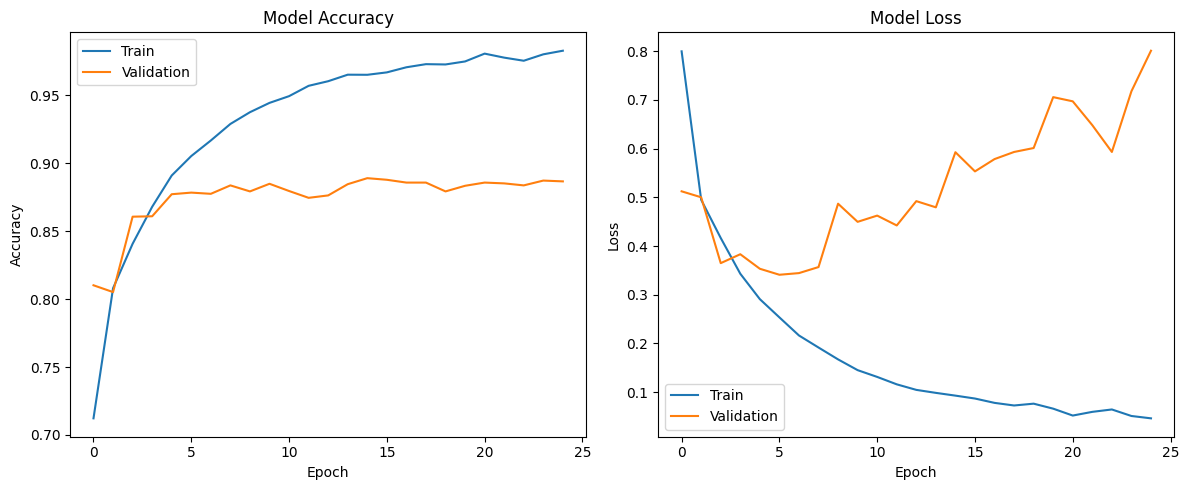

In [31]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

Plotting Confusion Matrix

In [32]:
# Make predictions
predictions = model.predict(testX)
y_pred = np.argmax(predictions, axis=1)  # Convert predictions to class labels

# Convert testY from one-hot encoded to class labels (integers)
y_true = np.argmax(testY, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

133/133 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step
[[ 684   16   22    1]
 [  61  938  197    7]
 [  49  133 1845   11]
 [  12    4   13  240]]


In [33]:
class_names = le.classes_

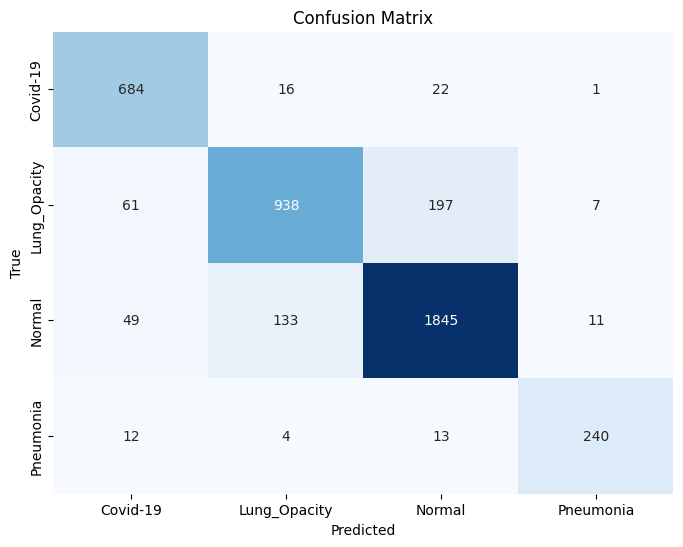

In [34]:
# Create DataFrame for the confusion matrix
Confusion_Matrix = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot the confusion matrix using seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(Confusion_Matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

classification report on test

In [36]:
# predIdxs = np.argmax(predIdxs, axis=1)
print(classification_report(y_true, y_pred, target_names=le.classes_, digits = 5))

              precision    recall  f1-score   support

    Covid-19    0.84864   0.94606   0.89470       723
Lung_Opacity    0.85976   0.77972   0.81779      1203
      Normal    0.88830   0.90530   0.89672      2038
   Pneumonia    0.92664   0.89219   0.90909       269

    accuracy                        0.87574      4233
   macro avg    0.88083   0.88082   0.87957      4233
weighted avg    0.87585   0.87574   0.87473      4233



Save Model and Label Encoder

In [37]:
# Save model and label encoder to backend/models directory
import os
import pickle

# Define the path to backend/models directory
models_dir = r'c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Project\Medical_Image_Analysis_System\backend\models'

# Create directory if it doesn't exist
os.makedirs(models_dir, exist_ok=True)

# Save model
model_path = os.path.join(models_dir, 'COVID19_Xray_Model.h5')
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save label encoder
label_encoder_path = os.path.join(models_dir, 'COVID19_Label_Encoder.pkl')
pickle.dump(le, open(label_encoder_path, 'wb'))
print(f"Label encoder saved to: {label_encoder_path}")

print("All files saved successfully!")

Model saved to: c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Project\Medical_Image_Analysis_System\backend\models\COVID19_Xray_Model.h5
Label encoder saved to: c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Project\Medical_Image_Analysis_System\backend\models\COVID19_Label_Encoder.pkl
All files saved successfully!


Load for inference

In [38]:
from tensorflow.keras.models import load_model
import pickle

# Define the path to backend/models directory
models_dir = r'c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Project\Medical_Image_Analysis_System\backend\models'

# Load the saved model
model_path = os.path.join(models_dir, 'COVID19_Xray_Model.h5')
model = load_model(model_path)
print(f"Model loaded from: {model_path}")

# Load label encoder
label_encoder_path = os.path.join(models_dir, 'COVID19_Label_Encoder.pkl')
le = pickle.load(open(label_encoder_path, 'rb'))
print(f"Label encoder loaded from: {label_encoder_path}")

print("All files loaded successfully!")

Model loaded from: c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Project\Medical_Image_Analysis_System\backend\models\COVID19_Xray_Model.h5
Label encoder loaded from: c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Project\Medical_Image_Analysis_System\backend\models\COVID19_Label_Encoder.pkl
All files loaded successfully!


Real Time Detection System

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


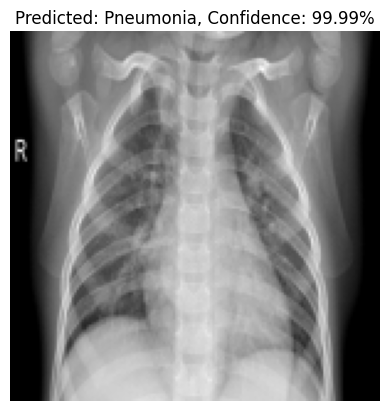

Predicted Label: Pneumonia, Confidence Score: 99.99%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


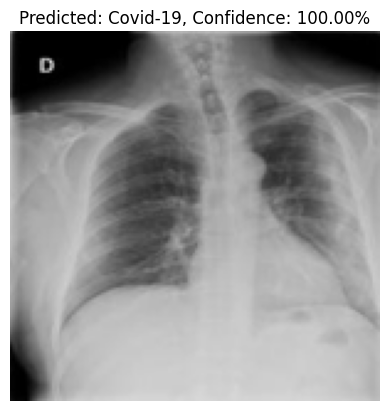

Predicted Label: Covid-19, Confidence Score: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


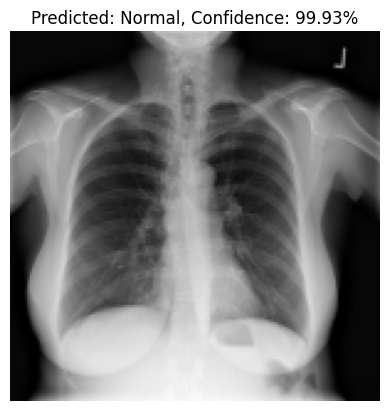

Predicted Label: Normal, Confidence Score: 99.93%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


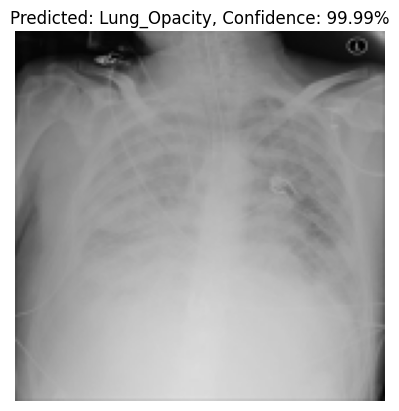

Predicted Label: Lung_Opacity, Confidence Score: 99.99%


In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detection_system(image_path, model, label_encoder, image_size=150):
    """
    Detection system function to classify an input image.

    Parameters:
    - image_path: The path to the image to classify.
    - model: The trained Keras model.
    - label_encoder: The LabelEncoder used to encode the labels.
    - image_size: The target size for resizing the image (default: 150x150).
    
    Returns:
    - predicted_label: The predicted class label.
    - confidence_score: The confidence score of the predicted class.
    """
    # Load the image from the provided path
    image = cv2.imread(image_path)
    
    if image is None:
        raise ValueError(f"Image not found at path: {image_path}")
    
    # Convert image from BGR to RGB format
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Resize the image to the same size as the training images
    image_resized = cv2.resize(image_rgb, (image_size, image_size))
    
    # Normalize the pixel values to the range [0, 1]
    image_normalized = image_resized / 255.0
    
    # Expand the dimensions to match the input shape for the model
    image_input = np.expand_dims(image_normalized, axis=0)
    
    # Predict the class of the image
    predictions = model.predict(image_input)
    
    # Get the predicted class index and confidence score
    predicted_index = np.argmax(predictions)
    confidence_score = predictions[0][predicted_index]
    
    # Decode the predicted index back to the original label
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]
    
    
    # Display the image with the predicted label and confidence score
    plt.imshow(image_resized)
    plt.title(f"Predicted: {predicted_label}, Confidence: {confidence_score*100:.2f}%")
    plt.axis('off')
    plt.show()

    return predicted_label, confidence_score

# Example usage - Test with local dataset paths
base_path = r'c:\Users\Abhay Tyagi\OneDrive - ABES\Desktop\4th Year Project\Datasets\COVID-19\COVID-19_Radiography_Dataset'

# Test Pneumonia image
image_path = os.path.join(base_path, r'Viral Pneumonia\images\Viral Pneumonia-1000.png')
predicted_label, confidence_score = detection_system(image_path, model, le)
print(f"Predicted Label: {predicted_label}, Confidence Score: {confidence_score*100:.2f}%")

# Test COVID image
image_path = os.path.join(base_path, r'COVID\images\COVID-1019.png')
predicted_label, confidence_score = detection_system(image_path, model, le)
print(f"Predicted Label: {predicted_label}, Confidence Score: {confidence_score*100:.2f}%")

# Test Normal image
image_path = os.path.join(base_path, r'Normal\images\Normal-10002.png')
predicted_label, confidence_score = detection_system(image_path, model, le)
print(f"Predicted Label: {predicted_label}, Confidence Score: {confidence_score*100:.2f}%")

# Test Lung Opacity image
image_path = os.path.join(base_path, r'Lung_Opacity\images\Lung_Opacity-1000.png')
predicted_label, confidence_score = detection_system(image_path, model, le)
print(f"Predicted Label: {predicted_label}, Confidence Score: {confidence_score*100:.2f}%")